In [1]:
# install.packages(c("dplyr", "tidyr", "ggplot2", "mgcv"))

In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(mgcv)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.



In [ ]:
data <- read.csv("log_dir/areds_cleaned.csv",
                 na.strings = c("-9", "NA", " ", "-1", "other"),
                 stringsAsFactors = TRUE)
# data <- data[data$summary != "nako_mae", ]
data <- data %>%
  rename(modelname = summary) %>%
  mutate(
    modelname = as.character(modelname),

    objective = case_when(
      modelname %in% c("simclr_inet_nako", "simclr_nako") ~ "simclr",
      modelname %in% c("retfound", "nako_mae", "nako_mae_scr")  ~ "mae",
      grepl("dino", modelname)                            ~ "dino",
      modelname == "resnet_imagenet"                      ~ "supervised",
      modelname == "scratch"                              ~ "none",
      TRUE                                                ~ NA_character_
    ),

    family = case_when(
      modelname %in% c("simclr_inet_nako", "simclr_nako",
                       "nako_mae", "nako_mae_scr")      ~ "SSL",
      modelname %in% c("retfound", "dino_meta", "dino_nako")      ~ "FM",
      modelname %in% c("resnet_imagenet", "scratch") ~ "baseline",
      TRUE                                           ~ NA_character_
    ),

    in_domain = case_when(
      modelname %in% c("simclr_inet_nako", "simclr_nako",
                       "nako_mae", "dino_nako", "retfound", "nako_mae_scr") ~ TRUE,
      modelname %in% c("dino_meta", "resnet_imagenet", "scratch") ~ FALSE,
      TRUE ~ NA
    ),

    across(c(objective, family), factor)
  )

# Verify every model mapped cleanly, no NAs in the derived factors.
data %>% count(modelname, objective, family, in_domain) %>%
  arrange(family, objective)

modelname,objective,family,in_domain,n
<chr>,<fct>,<fct>,<lgl>,<int>
scratch,none,baseline,FALSE,140
resnet_imagenet,supervised,baseline,FALSE,140
dino_meta,dino,FM,FALSE,140
dino_nako,dino,FM,TRUE,140
retfound,mae,FM,TRUE,140
nako_mae,mae,SSL,TRUE,140
nako_mae_scr,mae,SSL,TRUE,140
simclr_inet_nako,simclr,SSL,TRUE,140
simclr_nako,simclr,SSL,TRUE,140


In [3]:
stopifnot(!any(is.na(data$objective)),
          !any(is.na(data$family)),
          !any(is.na(data$in_domain)))

In [4]:
cell_means <- data %>%
  group_by(modelname, objective, family, in_domain,
           train_size, freeze_encoder, survival_head) %>%
  summarise(cindex = mean(cindex), ibs = mean(ibs), .groups = "drop")

# 8 models x 7 sizes x 2 heads x 2 freeze = 224 cells.
stopifnot(nrow(cell_means) == 224)

ERROR: Error: nrow(cell_means) == 224 is not TRUE


In [5]:
data$cell_id <- interaction(data$modelname, data$train_size,
                            data$survival_head, data$freeze_encoder,
                            drop = TRUE)

m_cindex <- gam(
  cindex ~ s(train_size,
             by = interaction(objective, freeze_encoder, survival_head),
             bs = "tp", k = 5)
         + interaction(objective, freeze_encoder, survival_head)
         + s(cell_id, bs = "re"),
  data = data, method = "REML"
)

summary(m_cindex)


Family: gaussian 
Link function: identity 

Formula:
cindex ~ s(train_size, by = interaction(objective, freeze_encoder, 
    survival_head), bs = "tp", k = 5) + interaction(objective, 
    freeze_encoder, survival_head) + s(cell_id, bs = "re")

Parametric coefficients:
                                                                         Estimate
(Intercept)                                                               0.79220
interaction(objective, freeze_encoder, survival_head)mae.0.linear         0.09694
interaction(objective, freeze_encoder, survival_head)none.0.linear        0.03529
interaction(objective, freeze_encoder, survival_head)simclr.0.linear      0.10332
interaction(objective, freeze_encoder, survival_head)supervised.0.linear  0.06944
interaction(objective, freeze_encoder, survival_head)dino.1.linear        0.10038
interaction(objective, freeze_encoder, survival_head)mae.1.linear        -0.01467
interaction(objective, freeze_encoder, survival_head)none.1.linear       


Method: REML   Optimizer: outer newton
full convergence after 10 iterations.
Gradient range [-0.001109833,0.0007197047]
(score -2431.272 & scale 0.0005348136).
eigenvalue range [-0.0001452208,626.8181].
Model rank =  352 / 352 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                                                                           k'
s(train_size):interaction(objective, freeze_encoder, survival_head)dino.0.linear         4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)mae.0.linear          4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)none.0.linear         4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)simclr.0.linear       4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)supervised.0.linear   4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)dino.1.lin

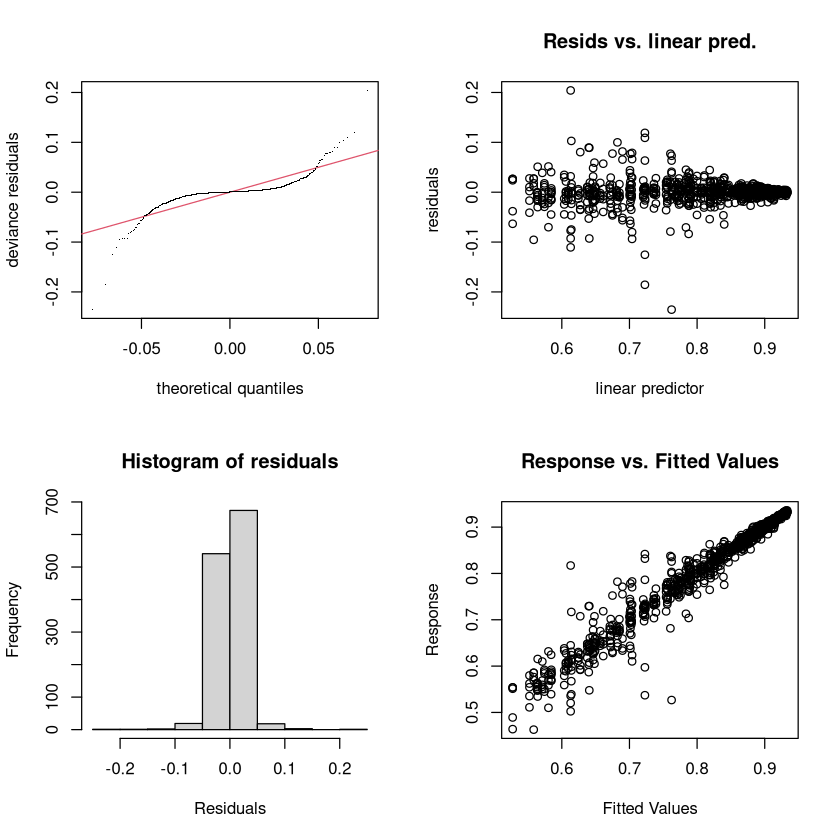

In [6]:
gam.check(m_cindex)


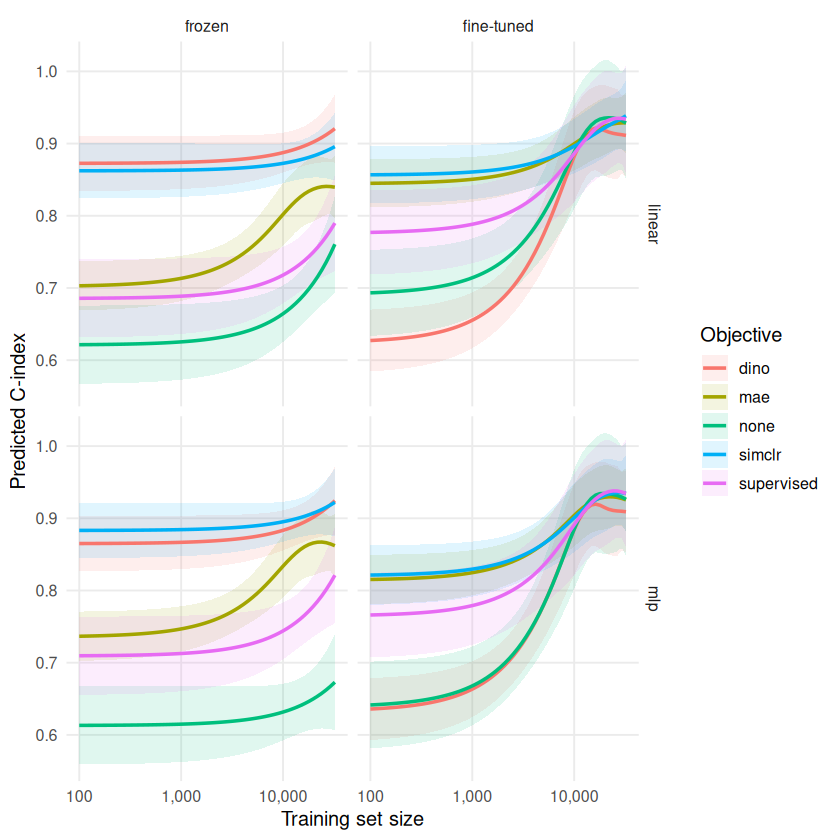

In [7]:
grid <- expand_grid(
  objective      = levels(data$objective),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear"),
  train_size     = exp(seq(log(100), log(32250), length.out = 60))
)
grid$cell_id <- data$cell_id[1]   # dummy; random effect excluded below

p <- predict(m_cindex, grid, se.fit = TRUE, exclude = "s(cell_id)")
grid <- grid %>%
  mutate(fit = p$fit, lo = p$fit - 1.96 * p$se.fit, hi = p$fit + 1.96 * p$se.fit,
         protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(grid, aes(train_size, fit, colour = objective, fill = objective)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.12, colour = NA) +
  geom_line(linewidth = 1) +
  facet_grid(survival_head ~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  labs(x = "Training set size", y = "Predicted C-index",
       colour = "Objective", fill = "Objective") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

In [8]:
g0       <- gam(cindex ~ s(train_size, by = interaction(freeze_encoder, survival_head), k = 5)
                       + interaction(freeze_encoder, survival_head),
                data = cell_means, method = "ML")

gobj     <- gam(cindex ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head), k = 5)
                       + interaction(objective, freeze_encoder, survival_head),
                data = cell_means, method = "ML")

gobj_fam <- gam(cindex ~ s(train_size, by = interaction(objective, family, freeze_encoder, survival_head), k = 5)
                       + interaction(objective, family, freeze_encoder, survival_head),
                data = cell_means, method = "ML")

gobj_dom <- gam(cindex ~ s(train_size, by = interaction(objective, in_domain, freeze_encoder, survival_head), k = 5)
                       + interaction(objective, in_domain, freeze_encoder, survival_head),
                data = cell_means, method = "ML")

AIC(g0, gobj, gobj_fam, gobj_dom)

,df,AIC
,<dbl>,<dbl>
g0,12.49412,-515.6596
gobj,53.01961,-719.4731
gobj_fam,59.26840,-700.2978
gobj_dom,63.08727,-696.4305


In [9]:
sapply(list(g0 = g0, gobj = gobj, gobj_fam = gobj_fam, gobj_dom = gobj_dom),
       \(m) summary(m)$dev.expl) |> round(4)

g0     gobj gobj_fam gobj_dom 
  0.3752   0.7983   0.7928   0.7959

In [10]:
decompose_subset <- function(df) {
  g0   <- gam(cindex ~ s(train_size, k = 5), data = df, method = "ML")
  gobj <- gam(cindex ~ s(train_size, by = objective, k = 5) + objective,
              data = df, method = "ML")
  gfam <- gam(cindex ~ s(train_size, by = interaction(objective, family), k = 5)
                     + interaction(objective, family), data = df, method = "ML")
  gdom <- gam(cindex ~ s(train_size, by = interaction(objective, in_domain), k = 5)
                     + interaction(objective, in_domain), data = df, method = "ML")
  tibble(
    dev_base = summary(g0)$dev.expl,
    dev_obj  = summary(gobj)$dev.expl,
    dev_fam  = summary(gfam)$dev.expl,
    dev_dom  = summary(gdom)$dev.expl,
    dAIC_obj = AIC(gobj) - AIC(g0),    # objective vs baseline
    dAIC_fam = AIC(gfam) - AIC(gobj),  # family beyond objective (+ = worse)
    dAIC_dom = AIC(gdom) - AIC(gobj)   # domain beyond objective  (+ = worse)
  )
}

regime_decomp <- cell_means %>%
  group_by(freeze_encoder, survival_head) %>%
  group_modify(~ decompose_subset(.x)) %>%
  ungroup()

regime_decomp

freeze_encoder,survival_head,dev_base,dev_obj,dev_fam,dev_dom,dAIC_obj,dAIC_fam,dAIC_dom
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,linear,0.4919536,0.7606384,0.7684071,0.7517650,-28.268887,2.019711,8.066761
0,mlp,0.5161522,0.6509278,0.6529205,0.6308530,-3.009133,3.659965,7.429460
1,linear,0.1665610,0.8967031,0.8991290,0.8967097,-111.585881,4.256588,3.996081
1,mlp,0.1225212,0.8770025,0.8752446,0.8770192,-104.247653,5.823179,3.991628


In [11]:
write.csv(regime_decomp, "csv_files/regime_decomp.csv", row.names = FALSE)

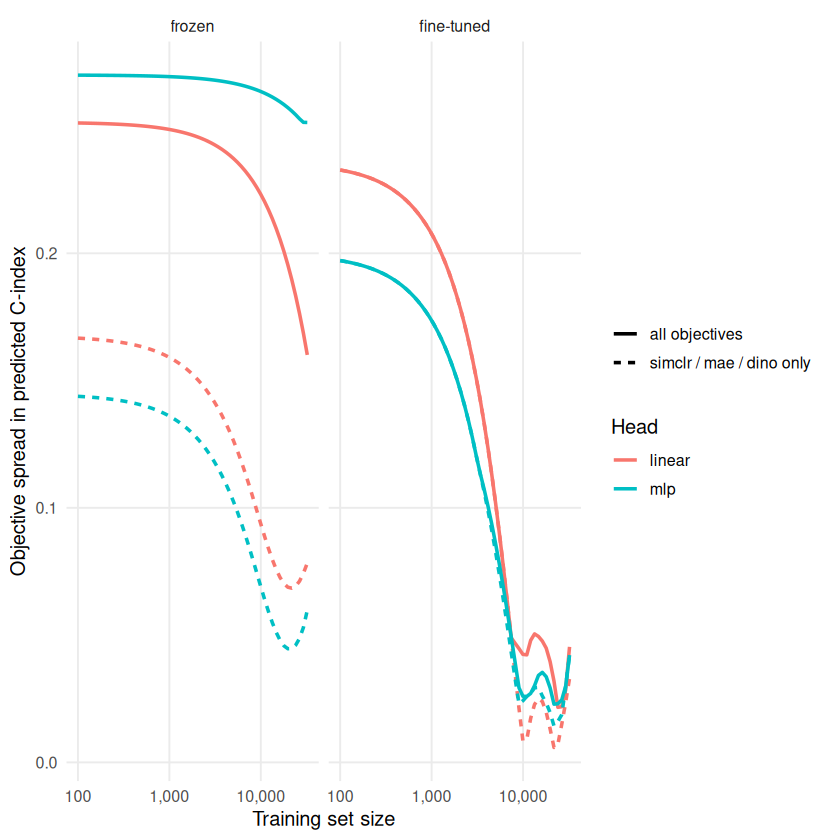

In [12]:
gobj_full <- gam(
  cindex ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head),
             bs = "tp", k = 5)
         + interaction(objective, freeze_encoder, survival_head),
  data = cell_means, method = "ML"
)

# Self-contained grid (does not depend on earlier chunks).
spread_grid <- expand_grid(
  objective      = levels(cell_means$objective),
  train_size     = exp(seq(log(100), log(32250), length.out = 60)),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear")
)
spread_grid$pred <- predict(gobj_full, newdata = spread_grid)

well_populated <- c("simclr", "mae", "dino")

spread_all <- spread_grid %>%
  group_by(freeze_encoder, survival_head, train_size) %>%
  summarise(spread = max(pred) - min(pred), .groups = "drop") %>%
  mutate(set = "all objectives")

spread_robust <- spread_grid %>%
  filter(objective %in% well_populated) %>%
  group_by(freeze_encoder, survival_head, train_size) %>%
  summarise(spread = max(pred) - min(pred), .groups = "drop") %>%
  mutate(set = "simclr / mae / dino only")

spread <- bind_rows(spread_all, spread_robust) %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(spread, aes(train_size, spread, colour = survival_head, linetype = set)) +
  geom_line(linewidth = 1) +
  facet_wrap(~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  scale_linetype_manual(values = c("all objectives" = "solid",
                                   "simclr / mae / dino only" = "22")) +
  labs(x = "Training set size", y = "Objective spread in predicted C-index",
       colour = "Head", linetype = NULL) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), legend.position = "right")

In [13]:
cm_ssl <- cell_means %>%
  filter(objective %in% c("simclr", "mae", "dino")) %>%
  mutate(objective = droplevels(objective))

regime_decomp_ssl <- cm_ssl %>%
  group_by(freeze_encoder, survival_head) %>%
  group_modify(~ decompose_subset(.x)) %>%   # reuses the function defined above
  ungroup()

regime_decomp_ssl

freeze_encoder,survival_head,dev_base,dev_obj,dev_fam,dev_dom,dAIC_obj,dAIC_fam,dAIC_dom
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,linear,0.4447791,0.8299735,0.8408524,0.8142191,-47.01399,0.9489842,9.629553
0,mlp,0.4708980,0.6445183,0.6472424,0.6271818,-11.25058,3.6348630,6.988072
1,linear,0.2071231,0.8564499,0.8618584,0.8564627,-71.68943,4.0232721,3.995749
1,mlp,0.2732281,0.7640969,0.7599947,0.7641397,-44.74530,5.8090499,3.991375


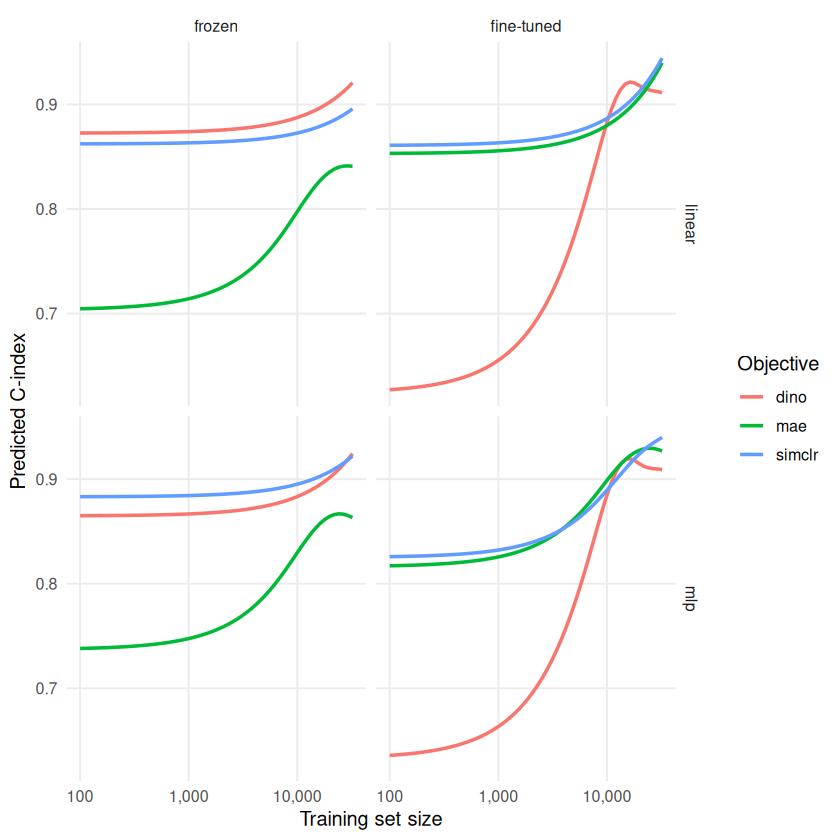

In [14]:
gobj_ssl <- gam(
  cindex ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head), k = 5)
         + interaction(objective, freeze_encoder, survival_head),
  data = cm_ssl, method = "ML"
)

grid_ssl <- expand_grid(
  objective      = levels(cm_ssl$objective),
  train_size     = exp(seq(log(100), log(32250), length.out = 60)),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear")
)
grid_ssl$pred <- predict(gobj_ssl, grid_ssl)
grid_ssl <- grid_ssl %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(grid_ssl, aes(train_size, pred, colour = objective)) +
  geom_line(linewidth = 1) +
  facet_grid(survival_head ~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  labs(x = "Training set size", y = "Predicted C-index", colour = "Objective") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

In [15]:
m_ibs <- gam(
  ibs ~ s(train_size,
          by = interaction(objective, freeze_encoder, survival_head),
          bs = "tp", k = 5)
      + interaction(objective, freeze_encoder, survival_head)
      + s(cell_id, bs = "re"),
  data = data, method = "REML"
)

summary(m_ibs)


Family: gaussian 
Link function: identity 

Formula:
ibs ~ s(train_size, by = interaction(objective, freeze_encoder, 
    survival_head), bs = "tp", k = 5) + interaction(objective, 
    freeze_encoder, survival_head) + s(cell_id, bs = "re")

Parametric coefficients:
                                                                           Estimate
(Intercept)                                                               0.0700571
interaction(objective, freeze_encoder, survival_head)mae.0.linear        -0.0103380
interaction(objective, freeze_encoder, survival_head)none.0.linear       -0.0033644
interaction(objective, freeze_encoder, survival_head)simclr.0.linear     -0.0099363
interaction(objective, freeze_encoder, survival_head)supervised.0.linear -0.0056966
interaction(objective, freeze_encoder, survival_head)dino.1.linear       -0.0054682
interaction(objective, freeze_encoder, survival_head)mae.1.linear         0.0071915
interaction(objective, freeze_encoder, survival_head)none.1.


Method: REML   Optimizer: outer newton
full convergence after 10 iterations.
Gradient range [-0.000474725,0.0002747113]
(score -4989.357 & scale 8.958878e-06).
Hessian positive definite, eigenvalue range [0.0001795232,623.5063].
Model rank =  352 / 352 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                                                                           k'
s(train_size):interaction(objective, freeze_encoder, survival_head)dino.0.linear         4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)mae.0.linear          4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)none.0.linear         4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)simclr.0.linear       4.00
s(train_size):interaction(objective, freeze_encoder, survival_head)supervised.0.linear   4.00
s(train_size):interaction(objective, freeze_encoder

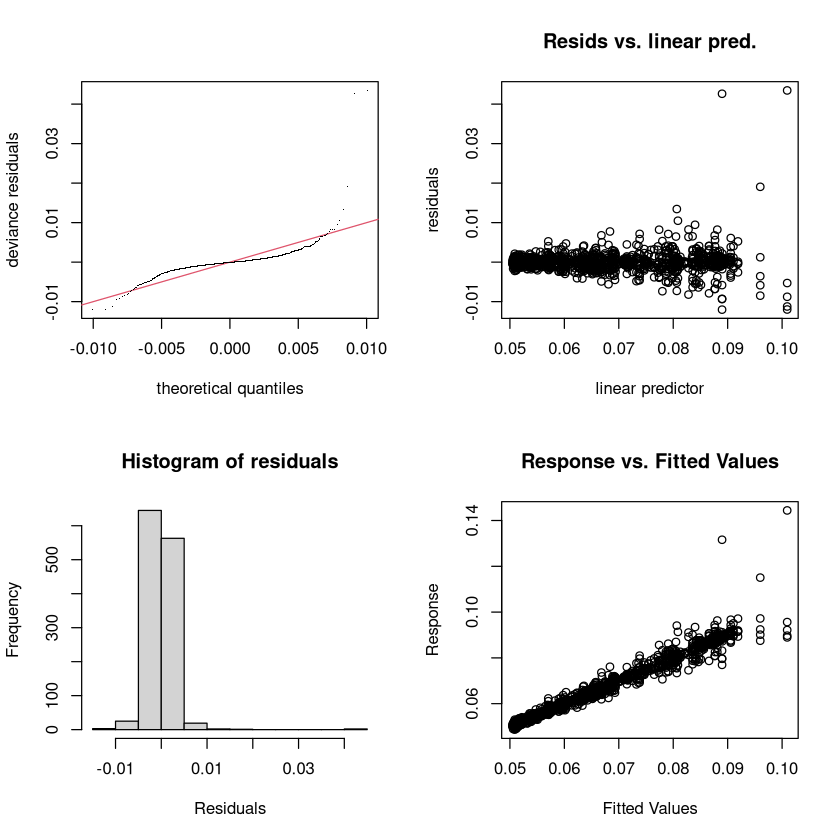

In [16]:
gam.check(m_ibs)


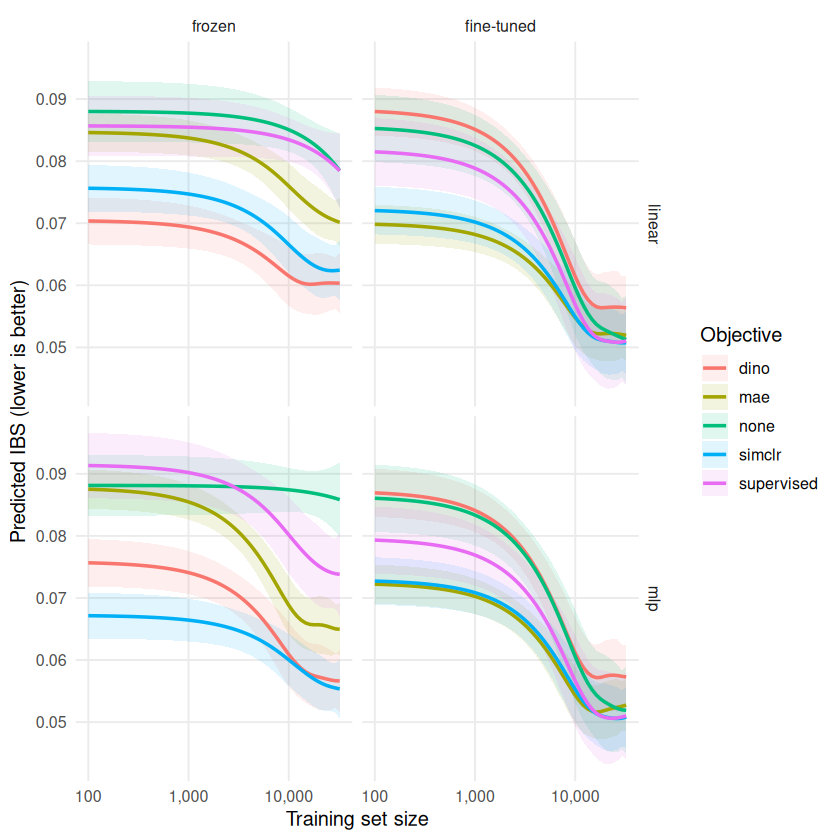

In [17]:
grid_ibs <- expand_grid(
  objective      = levels(data$objective),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear"),
  train_size     = exp(seq(log(100), log(32250), length.out = 60))
)
grid_ibs$cell_id <- data$cell_id[1]   # dummy; random effect excluded below

p_ibs <- predict(m_ibs, grid_ibs, se.fit = TRUE, exclude = "s(cell_id)")
grid_ibs <- grid_ibs %>%
  mutate(fit = p_ibs$fit,
         lo = p_ibs$fit - 1.96 * p_ibs$se.fit,
         hi = p_ibs$fit + 1.96 * p_ibs$se.fit,
         protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(grid_ibs, aes(train_size, fit, colour = objective, fill = objective)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.12, colour = NA) +
  geom_line(linewidth = 1) +
  facet_grid(survival_head ~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  labs(x = "Training set size", y = "Predicted IBS (lower is better)",
       colour = "Objective", fill = "Objective") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

In [18]:
g0_ibs       <- gam(ibs ~ s(train_size, by = interaction(freeze_encoder, survival_head), k = 5)
                        + interaction(freeze_encoder, survival_head),
                    data = cell_means, method = "ML")

gobj_ibs     <- gam(ibs ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head), k = 5)
                        + interaction(objective, freeze_encoder, survival_head),
                    data = cell_means, method = "ML")

gobj_fam_ibs <- gam(ibs ~ s(train_size, by = interaction(objective, family, freeze_encoder, survival_head), k = 5)
                        + interaction(objective, family, freeze_encoder, survival_head),
                    data = cell_means, method = "ML")

gobj_dom_ibs <- gam(ibs ~ s(train_size, by = interaction(objective, in_domain, freeze_encoder, survival_head), k = 5)
                        + interaction(objective, in_domain, freeze_encoder, survival_head),
                    data = cell_means, method = "ML")

AIC(g0_ibs, gobj_ibs, gobj_fam_ibs, gobj_dom_ibs)

,df,AIC
,<dbl>,<dbl>
g0_ibs,15.73345,-1694.153
gobj_ibs,66.70109,-1918.606
gobj_fam_ibs,75.20793,-1895.058
gobj_dom_ibs,75.24447,-1888.455


In [19]:
sapply(list(g0 = g0_ibs, gobj = gobj_ibs, gobj_fam = gobj_fam_ibs, gobj_dom = gobj_dom_ibs),
       \(m) summary(m)$dev.expl) |> round(4)

g0     gobj gobj_fam gobj_dom 
  0.6399   0.9014   0.8988   0.8961

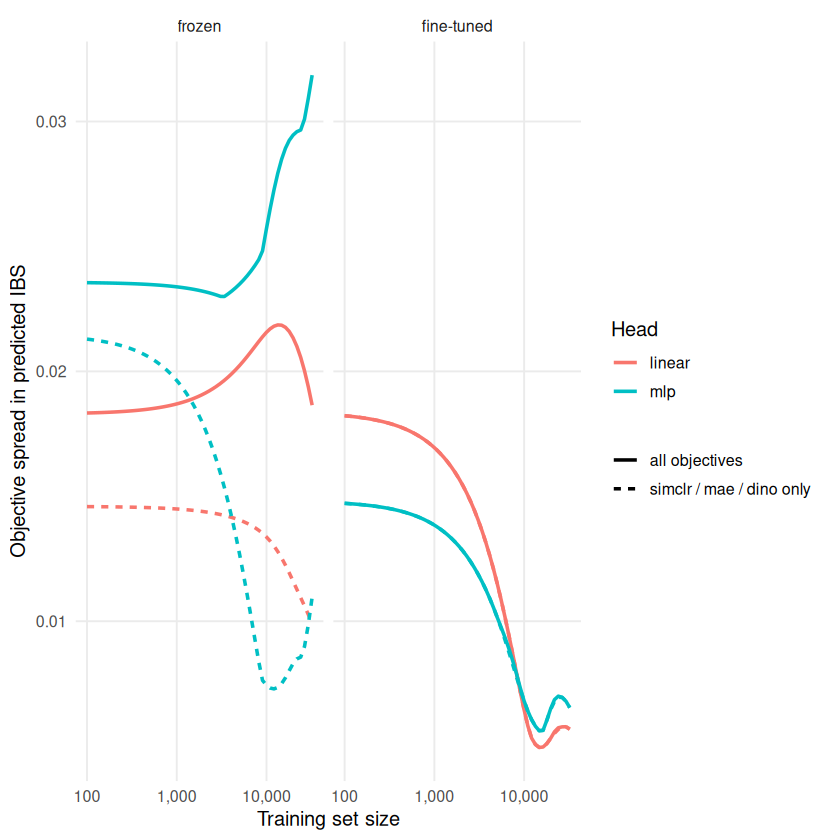

In [20]:
gobj_full_ibs <- gam(
  ibs ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head),
          bs = "tp", k = 5)
      + interaction(objective, freeze_encoder, survival_head),
  data = cell_means, method = "ML"
)

spread_grid_ibs <- expand_grid(
  objective      = levels(cell_means$objective),
  train_size     = exp(seq(log(100), log(32250), length.out = 60)),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear")
)
spread_grid_ibs$pred <- predict(gobj_full_ibs, newdata = spread_grid_ibs)

well_populated <- c("simclr", "mae", "dino")

spread_all_ibs <- spread_grid_ibs %>%
  group_by(freeze_encoder, survival_head, train_size) %>%
  summarise(spread = max(pred) - min(pred), .groups = "drop") %>%
  mutate(set = "all objectives")

spread_robust_ibs <- spread_grid_ibs %>%
  filter(objective %in% well_populated) %>%
  group_by(freeze_encoder, survival_head, train_size) %>%
  summarise(spread = max(pred) - min(pred), .groups = "drop") %>%
  mutate(set = "simclr / mae / dino only")

spread_ibs <- bind_rows(spread_all_ibs, spread_robust_ibs) %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(spread_ibs, aes(train_size, spread, colour = survival_head, linetype = set)) +
  geom_line(linewidth = 1) +
  facet_wrap(~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  scale_linetype_manual(values = c("all objectives" = "solid",
                                   "simclr / mae / dino only" = "22")) +
  labs(x = "Training set size", y = "Objective spread in predicted IBS",
       colour = "Head", linetype = NULL) +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(), legend.position = "right")

In [21]:
decompose_subset_ibs <- function(df) {
  g0   <- gam(ibs ~ s(train_size, k = 5), data = df, method = "ML")
  gobj <- gam(ibs ~ s(train_size, by = objective, k = 5) + objective,
              data = df, method = "ML")
  gfam <- gam(ibs ~ s(train_size, by = interaction(objective, family), k = 5)
                  + interaction(objective, family), data = df, method = "ML")
  gdom <- gam(ibs ~ s(train_size, by = interaction(objective, in_domain), k = 5)
                  + interaction(objective, in_domain), data = df, method = "ML")
  tibble(
    dev_base = summary(g0)$dev.expl,
    dev_obj  = summary(gobj)$dev.expl,
    dev_fam  = summary(gfam)$dev.expl,
    dev_dom  = summary(gdom)$dev.expl,
    dAIC_obj = AIC(gobj) - AIC(g0),
    dAIC_fam = AIC(gfam) - AIC(gobj),
    dAIC_dom = AIC(gdom) - AIC(gobj)
  )
}

regime_decomp_ibs <- cell_means %>%
  group_by(freeze_encoder, survival_head) %>%
  group_modify(~ decompose_subset_ibs(.x)) %>%
  ungroup()

regime_decomp_ibs

freeze_encoder,survival_head,dev_base,dev_obj,dev_fam,dev_dom,dAIC_obj,dAIC_fam,dAIC_dom
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,linear,0.7465491,0.8860017,0.8818437,0.8812797,-21.773311,5.533332,8.265733
0,mlp,0.7548447,0.8566331,0.8469556,0.8521000,-6.595256,8.158981,7.282835
1,linear,0.3242974,0.9447823,0.9444987,0.9405342,-130.730941,6.076753,10.329907
1,mlp,0.3564932,0.8956574,0.9017235,0.8811564,-91.982747,2.983137,9.630727


In [22]:
regime_decomp_ssl_ibs <- cm_ssl %>%
  group_by(freeze_encoder, survival_head) %>%
  group_modify(~ decompose_subset_ibs(.x)) %>%
  ungroup()

regime_decomp_ssl_ibs

freeze_encoder,survival_head,dev_base,dev_obj,dev_fam,dev_dom,dAIC_obj,dAIC_fam,dAIC_dom
<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,linear,0.7070952,0.8815460,0.8757835,0.8761262,-29.25150,5.649494,8.219836
0,mlp,0.7150422,0.8370375,0.8141097,0.8311271,-13.37751,9.295426,7.160717
1,linear,0.4779621,0.9236338,0.9218026,0.9104281,-76.74746,6.404635,11.650520
1,mlp,0.5485801,0.8499221,0.8571448,0.8341446,-42.02449,3.813821,7.685828


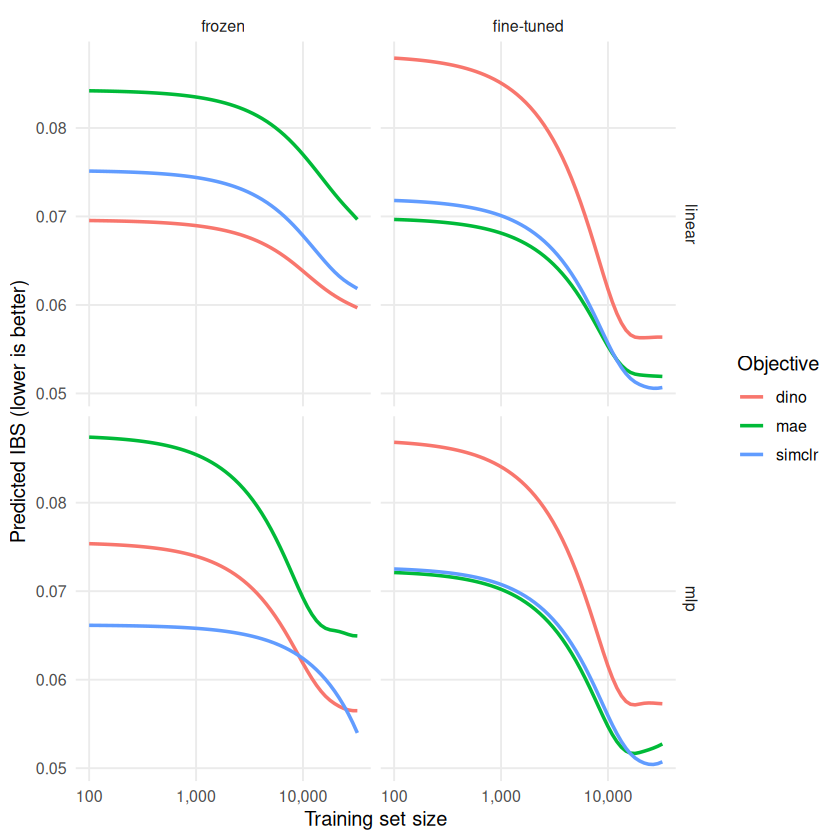

In [23]:
gobj_ssl_ibs <- gam(
  ibs ~ s(train_size, by = interaction(objective, freeze_encoder, survival_head), k = 5)
      + interaction(objective, freeze_encoder, survival_head),
  data = cm_ssl, method = "ML"
)

grid_ssl_ibs <- expand_grid(
  objective      = levels(cm_ssl$objective),
  train_size     = exp(seq(log(100), log(32250), length.out = 60)),
  freeze_encoder = c(0, 1),
  survival_head  = c("mlp", "linear")
)
grid_ssl_ibs$pred <- predict(gobj_ssl_ibs, grid_ssl_ibs)
grid_ssl_ibs <- grid_ssl_ibs %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned")))

ggplot(grid_ssl_ibs, aes(train_size, pred, colour = objective)) +
  geom_line(linewidth = 1) +
  facet_grid(survival_head ~ protocol) +
  scale_x_log10(breaks = c(100, 1000, 10000), labels = scales::label_comma()) +
  labs(x = "Training set size", y = "Predicted IBS (lower is better)",
       colour = "Objective") +
  theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank())

In [24]:
# All objectives (cell_means) — cindex
pred_full_cindex <- predict(gobj_full, newdata = spread_grid, se.fit = TRUE)
spread_grid$cindex_fit <- pred_full_cindex$fit
spread_grid$cindex_se  <- pred_full_cindex$se.fit

# All objectives (cell_means) — ibs
pred_full_ibs <- predict(gobj_full_ibs, newdata = spread_grid_ibs, se.fit = TRUE)
spread_grid_ibs$ibs_fit <- pred_full_ibs$fit
spread_grid_ibs$ibs_se  <- pred_full_ibs$se.fit

# SSL subset (cm_ssl) — cindex
pred_ssl_cindex <- predict(gobj_ssl, newdata = grid_ssl, se.fit = TRUE)
grid_ssl$cindex_fit <- pred_ssl_cindex$fit
grid_ssl$cindex_se  <- pred_ssl_cindex$se.fit

# SSL subset (cm_ssl) — ibs
pred_ssl_ibs <- predict(gobj_ssl_ibs, newdata = grid_ssl_ibs, se.fit = TRUE)
grid_ssl_ibs$ibs_fit <- pred_ssl_ibs$fit
grid_ssl_ibs$ibs_se  <- pred_ssl_ibs$se.fit

In [25]:
# All-objectives set: join cindex + ibs grids on shared columns
all_obj <- spread_grid %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned"))) %>%
  select(objective, train_size, protocol, survival_head, cindex_fit, cindex_se) %>%
  left_join(
    spread_grid_ibs %>%
      mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                               levels = c("frozen", "fine-tuned"))) %>%
      select(objective, train_size, protocol, survival_head, ibs_fit, ibs_se),
    by = c("objective", "train_size", "protocol", "survival_head")
  ) %>%
  mutate(level = "all objectives")

# SSL-only set: join cindex + ibs grids on shared columns
ssl_obj <- grid_ssl %>%
  mutate(protocol = factor(ifelse(freeze_encoder == 1, "frozen", "fine-tuned"),
                           levels = c("frozen", "fine-tuned"))) %>%
  select(objective, train_size, protocol, survival_head, cindex_fit, cindex_se) %>%
  left_join(
    grid_ssl_ibs %>%
      select(objective, train_size, protocol, survival_head, ibs_fit, ibs_se),
    by = c("objective", "train_size", "protocol", "survival_head")
  ) %>%
  mutate(level = "simclr / mae / dino only")

In [ ]:
final_combined <- bind_rows(all_obj, ssl_obj)
write.csv(final_combined, "csv_files/final_ibs_cindex_predictions.csv", row.names = FALSE)


In [27]:
dim(final_combined)      # returns c(nrow, ncol)
nrow(final_combined)     # just row count
ncol(final_combined)     # just column count
str(final_combined)      # shape + column types, very useful
glimpse(final_combined) 

[1] 1920    9

[1] 1920

[1] 9

tibble [1,920 × 9] (S3: tbl_df/tbl/data.frame)
 $ objective    : chr [1:1920] "dino" "dino" "dino" "dino" ...
 $ train_size   : num [1:1920] 100 100 100 100 110 ...
 $ protocol     : Factor w/ 2 levels "frozen","fine-tuned": 2 2 1 1 2 2 1 1 2 2 ...
 $ survival_head: chr [1:1920] "mlp" "linear" "mlp" "linear" ...
 $ cindex_fit   : num [1:1920(1d)] 0.637 0.628 0.865 0.873 0.637 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:1920] "1" "2" "3" "4" ...
 $ cindex_se    : num [1:1920(1d)] 0.0224 0.0224 0.02 0.02 0.0223 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:1920] "1" "2" "3" "4" ...
 $ ibs_fit      : num [1:1920(1d)] 0.0869 0.0879 0.0754 0.0697 0.0868 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:1920] "1" "2" "3" "4" ...
 $ ibs_se       : num [1:1920(1d)] 0.00202 0.00202 0.00198 0.0019 0.00202 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:1920] "1" "2" "3" "4" ...
 $ level        : chr [1:1920] "all objectives" "all objectives" "all objec

In [28]:
# IBS predictions
pred_ibs <- predict(gobj_ssl_ibs, grid_ssl_ibs, se.fit = TRUE)
grid_ssl_ibs$ibs_fit <- pred_ibs$fit
grid_ssl_ibs$ibs_se  <- pred_ibs$se.fit

# C-index predictions
pred_cindex <- predict(gobj_ssl, grid_ssl, se.fit = TRUE)
grid_ssl$cindex_fit <- pred_cindex$fit
grid_ssl$cindex_se  <- pred_cindex$se.fit

In [ ]:
grid_combined <- grid_ssl_ibs %>%
  select(objective, train_size, freeze_encoder, survival_head, protocol, ibs_fit, ibs_se) %>%
  left_join(
    grid_ssl %>% select(objective, train_size, freeze_encoder, survival_head, protocol, cindex_fit, cindex_se),
    by = c("objective", "train_size", "freeze_encoder", "survival_head", "protocol")
  ) %>%
  select(objective, train_size, protocol, survival_head, cindex_fit, cindex_se, ibs_fit, ibs_se)
write.csv(grid_combined, "csv_files/grid_ssl_combined_predictions.csv", row.names = FALSE)


In [30]:
dim(grid_combined)      # returns c(nrow, ncol)
nrow(grid_combined)     # just row count
ncol(grid_combined)     # just column count
str(grid_combined)      # shape + column types, very useful
glimpse(grid_combined)  # tidyverse version of str(), often more readable

[1] 720   8

[1] 720

[1] 8

tibble [720 × 8] (S3: tbl_df/tbl/data.frame)
 $ objective    : chr [1:720] "dino" "dino" "dino" "dino" ...
 $ train_size   : num [1:720] 100 100 100 100 110 ...
 $ protocol     : Factor w/ 2 levels "frozen","fine-tuned": 2 2 1 1 2 2 1 1 2 2 ...
 $ survival_head: chr [1:720] "mlp" "linear" "mlp" "linear" ...
 $ cindex_fit   : num [1:720(1d)] 0.636 0.627 0.865 0.873 0.636 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:720] "1" "2" "3" "4" ...
 $ cindex_se    : num [1:720(1d)] 0.0202 0.0202 0.018 0.018 0.0202 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:720] "1" "2" "3" "4" ...
 $ ibs_fit      : num [1:720(1d)] 0.0868 0.0879 0.0754 0.0695 0.0868 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:720] "1" "2" "3" "4" ...
 $ ibs_se       : num [1:720(1d)] 0.00202 0.00202 0.00197 0.00189 0.00202 ...
  ..- attr(*, "dimnames")=List of 1
  .. ..$ : chr [1:720] "1" "2" "3" "4" ...
Rows: 720
Columns: 8
$ objective     <chr> "dino", "dino", "dino", "dino", "dino", "d

In [31]:
nrow(all_obj)
nrow(ssl_obj)
table(final_combined$level)   # should show BOTH "all objectives" AND "simclr / mae / dino only"

[1] 1200

[1] 720


          all objectives simclr / mae / dino only 
                    1200                      720 

In [32]:
nlevels(cell_means$objective)
levels(cell_means$objective)

nlevels(cm_ssl$objective)
levels(cm_ssl$objective)

length(unique(grid_ssl$train_size))
length(unique(grid_ssl_ibs$train_size))
length(unique(spread_grid$train_size))

[1] 5

[1] "dino"       "mae"        "none"       "simclr"     "supervised"

[1] 3

[1] "dino"   "mae"    "simclr"

[1] 60

[1] 60

[1] 60